# Week 4 and 5: Summer project

Updating the $M_{\rm BH}-\sigma$ Plot with New Values from the MASSIVE Survey

In [122]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Para no tener warnings molestos de pandas
import warnings
warnings.filterwarnings('ignore')

## 1. Upload original table from McConnell & Ma (2013)
(Already done in week 2)

In [124]:
cols = ["Galaxy","Distance (Mpc)","MBH","MBH lower","MBH upper","method","sigma","sigma lower",
        "sigma upper","log(LV/Lsun)","error in log(LV/Lsun)","Mbulge/Msun",
        "radius of influence (arcsec)","Morphology","Profile"]

df_MM13 = pd.read_csv("McConnell_Ma_2013_ascii.txt", sep=r"\s+", names=cols, skiprows=17)
print(f"Galaxias en MM13: {len(df_MM13)}")
df_MM13.head()

Galaxias en MM13: 73


,Galaxy,Distance (Mpc),MBH,MBH lower,MBH upper,method,sigma,sigma lower,sigma upper,log(LV/Lsun),error in log(LV/Lsun),Mbulge/Msun,radius of influence (arcsec),Morphology,Profile
0,MW,0.008,4.100000e+06,3.500000e+06,4.700000e+06,star,103.0,83.0,123.0,0.00,0.00,0.000000e+00,43.00,S,NaN
1,A1836,157.500,3.900000e+09,3.300000e+09,4.300000e+09,gas,288.0,274.0,302.0,11.26,0.06,0.000000e+00,0.27,E,C
2,A3565,54.400,1.400000e+09,1.200000e+09,1.700000e+09,gas,322.0,306.0,338.0,11.24,0.06,0.000000e+00,0.22,E,C
3,Circ,4.000,1.700000e+06,1.400000e+06,2.100000e+06,maser,158.0,140.0,176.0,0.00,0.00,0.000000e+00,0.02,S,NaN
4,IC1459,30.900,2.800000e+09,1.600000e+09,3.900000e+09,star,315.0,299.0,331.0,10.96,0.06,3.070000e+11,0.81,E,C


## 2. Upload table from Liepold & Ma (2024)

This table contains the new BH masses for galaxies from the MASSIVE survey.  
The CSV has columns with unusual names such as `${M}_{K}^{2\mathrm{MASS}}$` that we don't need, so we extract only the useful information: name, M_BH, method, and reference.


In [125]:
cols_liepold = ["Galaxy", "dist1", "dist2", "dist3", "MK_2MASS", "MK_CFHT",
                "M_BH", "Mstar_dyn", "Method", "Reference"]
df_liepold = pd.read_csv("liepold.csv", names=cols_liepold, skiprows=1)
df_liepold = df_liepold[["Galaxy", "M_BH", "Method", "Reference"]].copy()
df_liepold = df_liepold.dropna(subset=["Galaxy"])
df_liepold

,Galaxy,M_BH,Method,Reference
0,NGC 57,NaN,Tri. stellar orbit,"J. Pilawa et al. 2024, in preparation"
1,NGC 315,2.02,CO gas,Boizelle et al. (2021)
2,NGC 708,8.98,Tri. stellar orbit,de Nicola et al. (2024)
3,NGC 997,3.28,CO gas,Dominiak et al. (2024)
4,NGC 1453,2.91,Tri. stellar orbit,Quenneville et al. (2022)
7,NGC 1600,19.05,Axi. stellar orbit,Thomas et al. (2016)
8,NGC 1684,1.40,CO gas,Dominiak et al. (2024)
9,NGC 2693,1.70,Tri. stellar orbit,Pilawa et al. (2022)
12,NGC 3842,8.63,Axi. stellar orbit,McConnell et al. (2011)
13,NGC 4472,2.44,Axi. stellar orbit,Rusli et al. (2013)


## 3. Upload the Veale et al. (2017) table with new sigmas

This table comes from the paper on the MASSIVE survey, which measures velocity dispersions.


In [126]:
cols_veale = ["Galaxy", "mk", "mstar", "lam", "sigc", "sigma",
              "gami", "gamo", "gamr", "h4avg", "h4grad",
              "env", "cluster", "mh", "delta", "nu"]
df_veale = pd.read_csv("Veale_ascii.txt", sep=r"\s+", comment="#",
                        names=cols_veale, skiprows=1)

df_veale = df_veale[df_veale["Galaxy"] != "gal"].copy()
df_veale = df_veale[["Galaxy", "sigma"]].copy()
df_veale["sigma"] = pd.to_numeric(df_veale["sigma"], errors="coerce")
df_veale = df_veale.rename(columns={"sigma": "sigma_Veale"})
df_veale

,Galaxy,sigma_Veale
1,NGC0057,251
2,NGC0080,222
3,NGC0315,341
4,NGC0383,257
5,NGC0410,247
...,...,...
86,NGC7550,224
87,NGC7556,243
88,NGC7618,265
89,NGC7619,277


## 4. The problem with galaxy names

Each table uses a different format for the names.
If we leave the names as they are, pandas cannot merge the tables correctly.
We will **normalize** all the names to a single format: `NGC4486`, `NGC57`, etc.

We do this using simple text (string) operations.

In [127]:
def normalizar_nombre(nombre):
    """Convierte cualquier formato de nombre a uno estandar: NGCxxxx (sin espacios ni ceros)."""
    if not isinstance(nombre, str):
        return nombre
    nombre = nombre.strip().upper()
    if nombre == "M87":
        return "NGC4486"

    # Si empieza con "N" solo (no NGC), convertirlo a NGC
    if nombre.startswith("N") and not nombre.startswith("NGC") and not nombre.startswith("NED"):
        numero = nombre[1:]  # todo despues de la N
        if numero.isdigit():
            return "NGC" + str(int(numero))  # int() le quita los ceros de adelante
    # Si empieza con NGC, sacarle el espacio y los ceros
    if nombre.startswith("NGC"):
        resto = nombre[3:].strip()  # todo despues de "NGC"
        if resto.isdigit():
            return "NGC" + str(int(resto))
    return nombre

In [128]:
df_MM13["Galaxy"]    = df_MM13["Galaxy"].apply(normalizar_nombre)
df_liepold["Galaxy"] = df_liepold["Galaxy"].apply(normalizar_nombre)
df_veale["Galaxy"]   = df_veale["Galaxy"].apply(normalizar_nombre)

In [129]:
df_MM13["Galaxy"].values

array(['MW', 'A1836', 'A3565', 'CIRC', 'IC1459', 'NGC221', 'NGC224',
       'NGC524', 'NGC821', 'NGC1023', 'NGC1194', 'NGC1300', 'NGC1316',
       'NGC1332', 'NGC1374', 'NGC1399', 'NGC1399', 'NGC1407', 'NGC1550',
       'NGC2273', 'NGC2549', 'NGC2787', 'NGC2960', 'NGC3031', 'NGC3091',
       'NGC3115', 'NGC3227', 'NGC3245', 'NGC3368', 'NGC3377', 'NGC3379',
       'NGC3384', 'NGC3393', 'NGC3489', 'NGC3585', 'NGC3607', 'NGC3608',
       'NGC3842', 'NGC3998', 'NGC4026', 'NGC4258', 'NGC4261', 'NGC4291',
       'NGC4342', 'NGC4374', 'NGC4388', 'NGC4459', 'NGC4472', 'NGC4473',
       'NGC4486', 'N4486A', 'NGC4564', 'NGC4594', 'NGC4596', 'NGC4649',
       'NGC4697', 'NGC4736', 'NGC4826', 'NGC4889', 'NGC5077', 'NGC5128',
       'NGC5516', 'NGC5576', 'NGC5845', 'NGC6086', 'NGC6251', 'NGC6264',
       'NGC6323', 'NGC7052', 'NGC7582', 'NGC7619', 'NGC7768', 'U3789'],
      dtype=object)

In [130]:
df_veale["Galaxy"].values

array(['NGC57', 'NGC80', 'NGC315', 'NGC383', 'NGC410', 'NGC499', 'NGC507',
       'NGC533', 'NGC545', 'NGC547', 'NGC665', 'UGC01332', 'NGC708',
       'NGC741', 'NGC777', 'NGC890', 'NGC910', 'NGC997', 'NGC1016',
       'NGC1060', 'NGC1132', 'NGC1129', 'NGC1167', 'NGC1226', 'IC0310',
       'NGC1272', 'UGC02783', 'NGC1453', 'NGC1497', 'NGC1600', 'NGC1573',
       'NGC1684', 'NGC1700', 'NGC2208', 'NGC2256', 'NGC2274', 'NGC2258',
       'NGC2320', 'UGC03683', 'NGC2332', 'NGC2340', 'UGC03894', 'NGC2418',
       'NGC2513', 'NGC2672', 'NGC2693', 'NGC2783', 'NGC2832', 'NGC2892',
       'NGC3158', 'NGC3209', 'NGC3462', 'NGC3562', 'NGC3615', 'NGC3805',
       'NGC3816', 'NGC3842', 'NGC3862', 'NGC3937', 'NGC4073', 'NGC4472',
       'NGC4555', 'NGC4816', 'NGC4839', 'NGC4874', 'NGC4889', 'NGC4914',
       'NGC5129', 'NGC5208', 'NGC5322', 'NGC5353', 'NGC5490', 'NGC5557',
       'NGC6223', 'NGC6375', 'UGC10918', 'NGC6482', 'NGC6575', 'NGC7052',
       'NGC7242', 'NGC7265', 'NGC7274', 'NGC7386', 'NGC

## 5. Last details before merging the tables

Before merging everything, we rename the columns so it is clear where each value comes from.
That way, they won't overwrite each other when we combine them.

In [131]:
df_MM13_clean = df_MM13[["Galaxy", "MBH", "MBH lower", "MBH upper",
                          "method", "sigma", "Morphology"]].copy()
df_MM13_clean = df_MM13_clean.rename(columns={"MBH":"M_BH_MM13","MBH lower":"M_BH_MM13_lower","MBH upper":"M_BH_MM13_upper","method":"Method_MM13",
    "sigma":"sigma_MM13","Morphology":"Morphology_MM13",
})
df_MM13_clean.head()

,Galaxy,M_BH_MM13,M_BH_MM13_lower,M_BH_MM13_upper,Method_MM13,sigma_MM13,Morphology_MM13
0,MW,4.100000e+06,3.500000e+06,4.700000e+06,star,103.0,S
1,A1836,3.900000e+09,3.300000e+09,4.300000e+09,gas,288.0,E
2,A3565,1.400000e+09,1.200000e+09,1.700000e+09,gas,322.0,E
3,CIRC,1.700000e+06,1.400000e+06,2.100000e+06,maser,158.0,S
4,IC1459,2.800000e+09,1.600000e+09,3.900000e+09,star,315.0,E


In [132]:
df_liepold_clean = df_liepold.rename(columns={
    "M_BH":     "M_BH_Liepold",
    "Method":   "Method_Liepold",
    "Reference": "Reference_Liepold",
})

# las masas de Liepold estan en unidades de 10^9 M_sun 
# Las pasamos a M_sun multiplicando por 1e9 para que coincidan con MM13
df_liepold_clean["M_BH_Liepold"] = df_liepold_clean["M_BH_Liepold"] * 1e9

df_liepold_clean

,Galaxy,M_BH_Liepold,Method_Liepold,Reference_Liepold
0,NGC57,NaN,Tri. stellar orbit,"J. Pilawa et al. 2024, in preparation"
1,NGC315,2.020000e+09,CO gas,Boizelle et al. (2021)
2,NGC708,8.980000e+09,Tri. stellar orbit,de Nicola et al. (2024)
3,NGC997,3.280000e+09,CO gas,Dominiak et al. (2024)
4,NGC1453,2.910000e+09,Tri. stellar orbit,Quenneville et al. (2022)
7,NGC1600,1.905000e+10,Axi. stellar orbit,Thomas et al. (2016)
8,NGC1684,1.400000e+09,CO gas,Dominiak et al. (2024)
9,NGC2693,1.700000e+09,Tri. stellar orbit,Pilawa et al. (2022)
12,NGC3842,8.630000e+09,Axi. stellar orbit,McConnell et al. (2011)
13,NGC4472,2.440000e+09,Axi. stellar orbit,Rusli et al. (2013)


## 6. Merge the 3 tables 

`merge` looks for rows where the "Galaxy" value matches and joins them.
`how="outer"` means: "keep ALL galaxies, even if they don't appear in all three tables."
If a galaxy is missing from a table, that cell appears as `NaN` (empty).

In [133]:
# Primero juntamos MM13 con Liepold
df_final = df_MM13_clean.merge(df_liepold_clean, on="Galaxy", how="outer")

# Despues juntamos el resultado con Veale
df_final = df_final.merge(df_veale, on="Galaxy", how="outer")


In [134]:

#Agregamos las columnas solicitadas
def asignar_flag(row):
    x = row['M_BH_MM13']
    y = row['M_BH_Liepold']
    z = row['sigma_Veale']
    if pd.notna(x) and pd.notna(y):
        return "MM13_updated"
    elif pd.notna(x) and pd.isna(y):
        return "MM13_original"
    elif pd.isna(x) and pd.notna(y):
        return "LM24_new"
    elif pd.isna(x) and pd.isna(y) and pd.notna(z):
        return "VP17_sigma"
    else:
        return np.nan 

def asignar_referencia(row):
    x = row['M_BH_MM13']
    y = row['M_BH_Liepold']
    z = row['sigma_Veale']
    if pd.notna(z) and pd.notna(y) and pd.isna(x):
        return "LM24_and_VP17"
    elif pd.notna(x) and pd.isna(y) and pd.isna(z):
        return "MM13"
    elif pd.isna(x) and pd.notna(y) and pd.isna(z):
        return "LM24"
    elif pd.isna(x) and pd.isna(y) and pd.notna(z):
        return "VP17"
    else:
        return np.nan 

df_final['Source_flag'] = df_final.apply(asignar_flag, axis=1)
df_final['References'] = df_final.apply(asignar_referencia, axis=1)
df_final

,Galaxy,M_BH_MM13,M_BH_MM13_lower,M_BH_MM13_upper,Method_MM13,sigma_MM13,Morphology_MM13,M_BH_Liepold,Method_Liepold,Reference_Liepold,sigma_Veale,Source_flag,References
0,A1836,3.900000e+09,3.300000e+09,4.300000e+09,gas,288.0,E,NaN,NaN,NaN,NaN,MM13_original,MM13
1,A3565,1.400000e+09,1.200000e+09,1.700000e+09,gas,322.0,E,NaN,NaN,NaN,NaN,MM13_original,MM13
2,CIRC,1.700000e+06,1.400000e+06,2.100000e+06,maser,158.0,S,NaN,NaN,NaN,NaN,MM13_original,MM13
3,IC0310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,VP17_sigma,VP17
4,IC1459,2.800000e+09,1.600000e+09,3.900000e+09,star,315.0,E,NaN,NaN,NaN,NaN,MM13_original,MM13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,UGC01332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,253.0,VP17_sigma,VP17
154,UGC02783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,266.0,VP17_sigma,VP17
155,UGC03683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,257.0,VP17_sigma,VP17
156,UGC03894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,255.0,VP17_sigma,VP17


# Updated $M_{\rm BH}-\sigma$ plot  

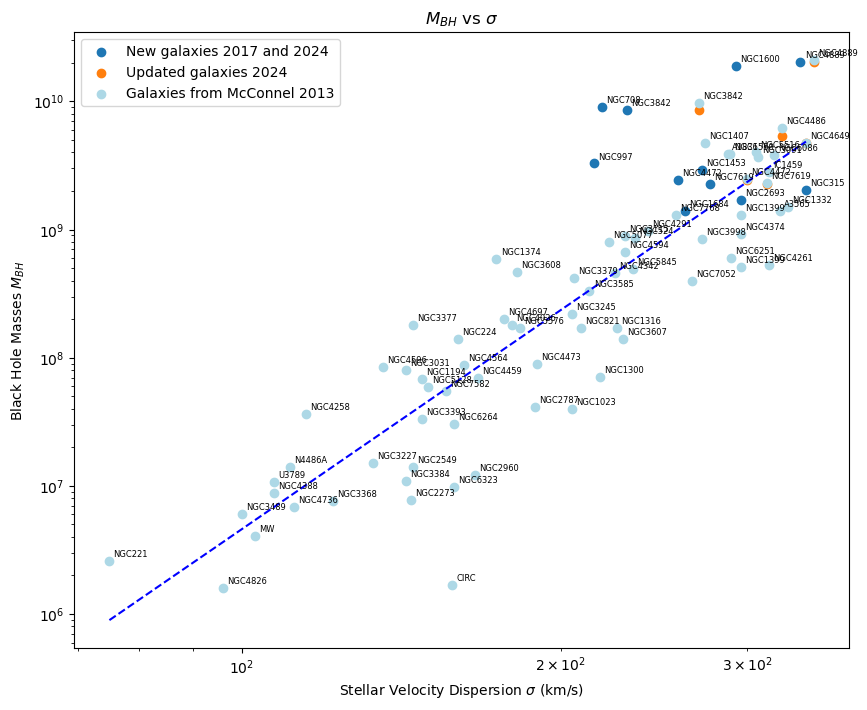

Global: alpha = 8.3709, beta = 5.6768


In [140]:
ig,ax=plt.subplots(figsize=(10, 8))
plt.ylabel("Black Hole Masses $M_{BH}$")
plt.xlabel("Stellar Velocity Dispersion $\sigma$ (km/s)")
plt.xscale("log")
plt.yscale("log")
plt.title("$M_{BH}$ vs $\sigma$")

mask = df_final['sigma_Veale'].notna() & df_final['M_BH_Liepold'].notna() # mask: solo filas con valores finitos en ambas
plt.scatter(df_final.loc[mask, 'sigma_Veale'], df_final.loc[mask, 'M_BH_Liepold'], label= 'New galaxies 2017 and 2024')
mask = df_final['sigma_MM13'].notna() & df_final['M_BH_Liepold'].notna()
plt.scatter(df_final.loc[mask, 'sigma_MM13'], df_final.loc[mask, 'M_BH_Liepold'], label= 'Updated galaxies 2024')
plt.scatter(df_final["sigma_MM13"],df_final["M_BH_MM13"], color="lightblue", label="Galaxies from McConnel 2013")

for i, row in df_final.iterrows():
    plt.annotate(
        row["Galaxy"],
        (row["sigma_MM13"], row["M_BH_MM13"]),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=6)
for i, row in df_final.iterrows():
    plt.annotate(
        row["Galaxy"],
        (row["sigma_Veale"], row["M_BH_Liepold"]),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=6)
#fit
df_final['MBH'] = df_final['M_BH_Liepold'].fillna(df_final['M_BH_MM13'])
df_final['sigma'] = df_final['sigma_Veale'].fillna(df_final['sigma_MM13'])
logx = np.log10(df_final["sigma"] / 200)
logy = np.log10(df_final["MBH"])
mask = np.isfinite(logx) & np.isfinite(logy)
coefs = np.polyfit(logx[mask], logy[mask], 1)
beta_global, alpha_global = coefs[0], coefs[1]
x = np.linspace(logx.min(), logx.max(), 100)
y = beta_global * x + alpha_global
ax.plot(10**(x + np.log10(200)), 10**y, linestyle="--", c="b") 

plt.legend()
plt.savefig("MBH_vs_sigma.jpg", dpi=300, bbox_inches="tight") 
plt.show()
print(f"Global: alpha = {alpha_global:.4f}, beta = {beta_global:.4f}")

In [141]:
print(df_final[['M_BH_Liepold', 'M_BH_MM13', 'MBH', 'Source_flag']].head(40))
print("NaN restantes en MBH:", df_final['MBH'].isna().sum()) 
#comprobamos que cada fila toma el valor correcto según qué columna tenía disponible sin duplicar ni perder datos

    M_BH_Liepold     M_BH_MM13           MBH    Source_flag
0            NaN  3.900000e+09  3.900000e+09  MM13_original
1            NaN  1.400000e+09  1.400000e+09  MM13_original
2            NaN  1.700000e+06  1.700000e+06  MM13_original
3            NaN           NaN           NaN     VP17_sigma
4            NaN  2.800000e+09  2.800000e+09  MM13_original
5            NaN  4.100000e+06  4.100000e+06  MM13_original
6            NaN  1.400000e+07  1.400000e+07  MM13_original
7            NaN           NaN           NaN     VP17_sigma
8            NaN  4.000000e+07  4.000000e+07  MM13_original
9            NaN           NaN           NaN     VP17_sigma
10           NaN           NaN           NaN     VP17_sigma
11           NaN           NaN           NaN     VP17_sigma
12           NaN           NaN           NaN     VP17_sigma
13           NaN  6.800000e+07  6.800000e+07  MM13_original
14           NaN           NaN           NaN     VP17_sigma
15           NaN           NaN          

In [142]:
df_final.to_csv("df_final.csv", index=False)